# Modelado

En este notebook se construye un modelo de clasificación capaz de predecir si un ECG corresponde a un paciente con una condición **Normal** o **Anormal**, utilizando las variables clínicas disponibles tras el proceso de limpieza y análisis exploratorio.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

from pathlib import Path

# Establecer la ruta del proyecto para importar módulos desde src
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

from src.modeling import (
    preparar_dataset,
    codificar_variables,
    separar_xy,
    dividir_dataset,
    evaluar_modelo,
)


In [73]:
df = pd.read_csv("../data/clean-data/pacientes_clean.csv")

df.head()

,id_paciente,edad_paciente,sexo,peso_kg,altura_cm,fecha_registro,frecuencia_cardiaca_media_bpm,derivacion_ecg,frecuencia_muestreo_hz,etiqueta
0,P0305,82.0,M,69.8,168.0,2023-10-04,69.4,II,250,Normal
1,P0500,58.0,M,70.9,178.9,2023-04-23,79.2,II,250,Normal
2,P0442,49.0,M,84.2,173.1,2023-01-25,72.7,II,250,Normal
3,P0154,39.0,F,80.5,156.4,2023-06-24,87.0,II,250,Anormal
4,P0479,22.0,F,78.7,165.5,2023-01-28,77.8,II,250,Normal


In [74]:
# Verificar que el dataFrame está limpio
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_paciente                    500 non-null    str    
 1   edad_paciente                  500 non-null    float64
 2   sexo                           500 non-null    str    
 3   peso_kg                        500 non-null    float64
 4   altura_cm                      500 non-null    float64
 5   fecha_registro                 500 non-null    str    
 6   frecuencia_cardiaca_media_bpm  500 non-null    float64
 7   derivacion_ecg                 500 non-null    str    
 8   frecuencia_muestreo_hz         500 non-null    int64  
 9   etiqueta                       500 non-null    str    
dtypes: float64(4), int64(1), str(5)
memory usage: 39.2 KB


## Preparación de los datos

Como parte del preprocesamiento para el entrenamiento del modelo, se eliminaron las columnas que no aportan información predictiva (`id_paciente`, `fecha_registro`, `frecuencia_muestreo_hz` y `derivacion_ecg`).

Posteriormente, las variables categóricas fueron codificadas mediante `LabelEncoder` y el conjunto de datos se dividió en entrenamiento (80 %) y prueba (20 %) utilizando un muestreo estratificado para conservar la distribución de la variable objetivo.

In [75]:
df = preparar_dataset(df)

df, encoders = codificar_variables(df)

X, y = separar_xy(df)

X_train, X_test, y_train, y_test = dividir_dataset(X, y)

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   edad_paciente                  500 non-null    float64
 1   sexo                           500 non-null    int64  
 2   peso_kg                        500 non-null    float64
 3   altura_cm                      500 non-null    float64
 4   frecuencia_cardiaca_media_bpm  500 non-null    float64
 5   etiqueta                       500 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 23.6 KB


In [77]:
print(X_train.shape)
print(X_test.shape)

(400, 5)
(100, 5)


In [ ]:
# Generamos el dataset final que se usará para el modelo, que contiene las variables codificadas y la variable objetivo
df.to_csv(
    "../data/model-data/pacientes_model.csv",
    index=False
)

## Selección del modelo

Como modelo baseline se utilizará una **Regresión Logística**.

La elección se basa en las siguientes razones:

- Es un algoritmo ampliamente utilizado como punto de partida en problemas de clasificación binaria.
- Permite obtener un modelo sencillo, interpretable y fácil de reproducir.
- Requiere un número reducido de hiperparámetros, lo que facilita evaluar el impacto de la preparación de los datos.
- El objetivo de esta prueba técnica no es maximizar el rendimiento, sino construir una línea base sólida sobre la cual puedan compararse modelos más complejos en trabajos futuros.

In [78]:
modelo = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [79]:
y_pred = modelo.predict(X_test)

In [80]:
metricas = evaluar_modelo(y_test, y_pred)

metricas

{'accuracy': 0.75,
 'precision': 0.7692307692307693,
 'recall': 0.8333333333333334,
 'f1': 0.8}

In [81]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Anormal"]
    )
)

              precision    recall  f1-score   support

      Normal       0.71      0.62      0.67        40
     Anormal       0.77      0.83      0.80        60

    accuracy                           0.75       100
   macro avg       0.74      0.73      0.73       100
weighted avg       0.75      0.75      0.75       100



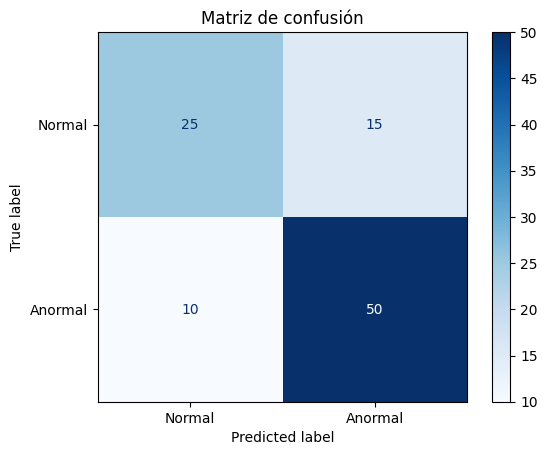

In [82]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Normal", "Anormal"],
    cmap="Blues"
)

plt.title("Matriz de confusión")
plt.show()

### Interpretación de los resultados

La matriz de confusión muestra que el modelo logra clasificar correctamente la mayoría de los registros. De los pacientes con ECG **Normal**, 25 fueron clasificados correctamente y 15 fueron identificados como **Anormal**. Por otro lado, de los pacientes con ECG **Anormal**, el modelo clasificó correctamente 50 casos y solo 10 fueron predichos como **Normal**.

En términos generales, el modelo presenta una mejor capacidad para identificar pacientes con ECG **Anormal**, lo cual se refleja en un **Recall de 0.83**. Esto significa que logra detectar aproximadamente el 83 % de los pacientes que realmente presentan una anomalía.

La **Precisión de 0.77** indica que, cuando el modelo predice que un paciente es **Anormal**, acierta cerca del 77 % de las veces. Esto implica que existen algunos falsos positivos, aunque en un contexto clínico resulta generalmente más aceptable realizar evaluaciones adicionales a un paciente sano que dejar sin detectar una posible anomalía.

El **Accuracy de 0.75** muestra que el modelo clasifica correctamente tres de cada cuatro registros. Sin embargo, esta métrica no se analiza de forma aislada debido a la ligera diferencia en la distribución de las clases observada durante el EDA.

Finalmente, el **F1-score de 0.80** refleja un buen equilibrio entre la precisión y la capacidad de detección del modelo, por lo que la Regresión Logística constituye un baseline adecuado para este problema de clasificación. Aunque existe margen de mejora, los resultados obtenidos son consistentes para una primera aproximación y proporcionan una base sólida para evaluar modelos más complejos en el futuro.

-----------------------------------

## Importancia de Variables
A mi gusto, es importante que se pueda visualizar, cuales fueron las variables mas importantes al momento de la creacion del modelo, para esto se puede observar los coeficientes de la regresion logistica, y ver cuales fueron las variables que mas aportaron al momento de la prediccion.

In [67]:
coeficientes = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": modelo.coef_[0]
})

coeficientes["Abs"] = coeficientes["Coeficiente"].abs()

coeficientes = coeficientes.sort_values(
    "Abs",
    ascending=False
)

coeficientes

,Variable,Coeficiente,Abs
4,frecuencia_cardiaca_media_bpm,-0.131329,0.131329
1,sexo,0.123439,0.123439
3,altura_cm,-0.041471,0.041471
2,peso_kg,0.032029,0.032029
0,edad_paciente,-0.016327,0.016327


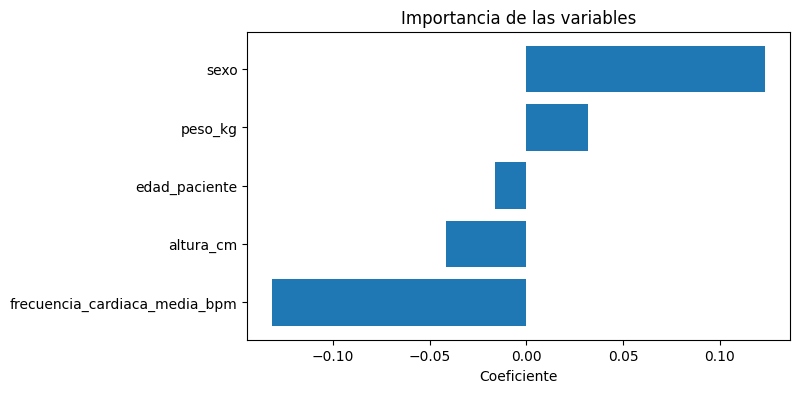

In [68]:
coeficientes = coeficientes.sort_values("Coeficiente")

plt.figure(figsize=(7,4))

plt.barh(
    coeficientes["Variable"],
    coeficientes["Coeficiente"]
)

plt.xlabel("Coeficiente")

plt.title("Importancia de las variables")

plt.show()

---------------------------

# Comparación entre el dataset original y el dataset limpio

Hasta este punto el modelo fue entrenado utilizando el conjunto de datos limpio obtenido tras las etapas de calidad de datos y preprocesamiento.

Sin embargo, para la prueba técnica pues hay que analizar, qué habría ocurrido si el entrenamiento se realizara directamente sobre el dataset original.

Para responder esta pregunta, se entrenará el mismo modelo de Regresión Logística utilizando ambos conjuntos de datos, manteniendo exactamente la misma metodología de preparación y evaluación. De esta forma, cualquier diferencia observada en las métricas podrá atribuirse principalmente al proceso de limpieza realizado.

Esta comparación permite evaluar el impacto de decisiones como:

- Eliminación de registros duplicados.
- Corrección de edades fuera del rango fisiológico.
- Tratamiento de valores faltantes.
- Eliminación de variables sin capacidad predictiva.

El objetivo no es demostrar que la limpieza incrementa necesariamente el accuracy, sino verificar cómo influye en la estabilidad y calidad del proceso de entrenamiento, gracias :).

In [61]:
from src.limpieza_datos import (
    imputar_numericas_con_mediana,
    imputar_categorica_con_moda,
    
)

df_original = pd.read_csv("../data/raw-data/pacientes.csv", sep=";")


In [62]:
df_original = preparar_dataset(df_original)

df_original = imputar_numericas_con_mediana(
    df_original,
    ["edad_paciente", "peso_kg", "altura_cm"]
)

df_original = imputar_categorica_con_moda(
    df_original,
    "sexo"
)

df_original, _ = codificar_variables(df_original)

In [ ]:
# Separar variables
X_original, y_original = separar_xy(df_original)

X_train_original, X_test_original, y_train_original, y_test_original = dividir_dataset(
    X_original,
    y_original
)

# Entrenamiento
modelo_original = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo_original.fit(
    X_train_original,
    y_train_original
)

y_pred_original = modelo_original.predict(X_test_original)

# Métricas
metricas_original = evaluar_modelo(
    y_test_original,
    y_pred_original
)

metricas_original

{'accuracy': 0.7766990291262136,
 'precision': 0.782608695652174,
 'recall': 0.8709677419354839,
 'f1': 0.8244274809160306}

In [64]:
comparacion = pd.DataFrame(
    [metricas_original, metricas],
    index=["Preparación mínima", "Dataset limpio"]
)

comparacion

,accuracy,precision,recall,f1
Preparación mínima,0.776699,0.782609,0.870968,0.824427
Dataset limpio,0.750000,0.769231,0.833333,0.800000


# Conclusiones

En este notebook se construyó un modelo baseline de clasificación utilizando Regresión Logística para identificar registros de ECG normales y anormales.

El modelo alcanzó un Accuracy de 75 %, un Recall de 83 % y un F1-score de 0.80, mostrando un desempeño adecuado para una primera aproximación.

La comparación con el dataset sometido únicamente a una preparación mínima evidenció que el proceso de limpieza no incrementó las métricas de clasificación en este caso particular. Sin embargo, permitió obtener un conjunto de datos consistente, libre de registros duplicados, valores imposibles e inconsistencias, garantizando un pipeline de entrenamiento más confiable y reproducible.

Los resultados obtenidos constituyen una línea base sobre la cual podrán evaluarse modelos más complejos y estrategias adicionales de ingeniería de características.